# 가우시안 혼합 분포의 밀도와 스코어 함수

In [292]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False

## 1. 혼합 가우시안 정의

In [293]:
means = np.array([
    [-1.5,  1.5],
    [ 1.5,  1.5],
    [-1.5, -1.5],
])
sigma = 0.6
weights = np.array([1 / 3, 1 / 3, 1 / 3])

## 2. 밀도 함수 $p(x)$

In [294]:
def density(x1, x2, w=None):
    """p(x) = sum_k w_k * N(x; mu_k, sigma^2 I). w를 지정하면 혼합 비율을 바꿔볼 수 있다."""
    if w is None:
        w = weights
    p = np.zeros_like(x1)
    for wk, mu in zip(w, means):
        d2 = (x1 - mu[0]) ** 2 + (x2 - mu[1]) ** 2
        p += wk * np.exp(-d2 / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
    return p

## 3. 스코어 함수 $\nabla_x \log p(x)$

In [295]:
def score(x1, x2, w=None):
    if w is None:
        w = weights
    p = density(x1, x2, w=w)
    grad_x1 = np.zeros_like(x1)
    grad_x2 = np.zeros_like(x2)
    for wk, mu in zip(w, means):
        d2 = (x1 - mu[0]) ** 2 + (x2 - mu[1]) ** 2
        n_k = np.exp(-d2 / (2 * sigma ** 2)) / (2 * np.pi * sigma ** 2)
        responsibility = wk * n_k / p
        grad_x1 += responsibility * (-(x1 - mu[0]) / sigma ** 2)
        grad_x2 += responsibility * (-(x2 - mu[1]) / sigma ** 2)
    return grad_x1, grad_x2

## 4. 격자 준비

In [296]:
lim = 4

fine = np.linspace(-lim, lim, 300)
X1_fine, X2_fine = np.meshgrid(fine, fine)
P = density(X1_fine, X2_fine)

coarse = np.linspace(-lim, lim, 18)
X1_c, X2_c = np.meshgrid(coarse, coarse)
U, V = score(X1_c, X2_c)
magnitude = np.sqrt(U ** 2 + V ** 2)

## 5. 시각화

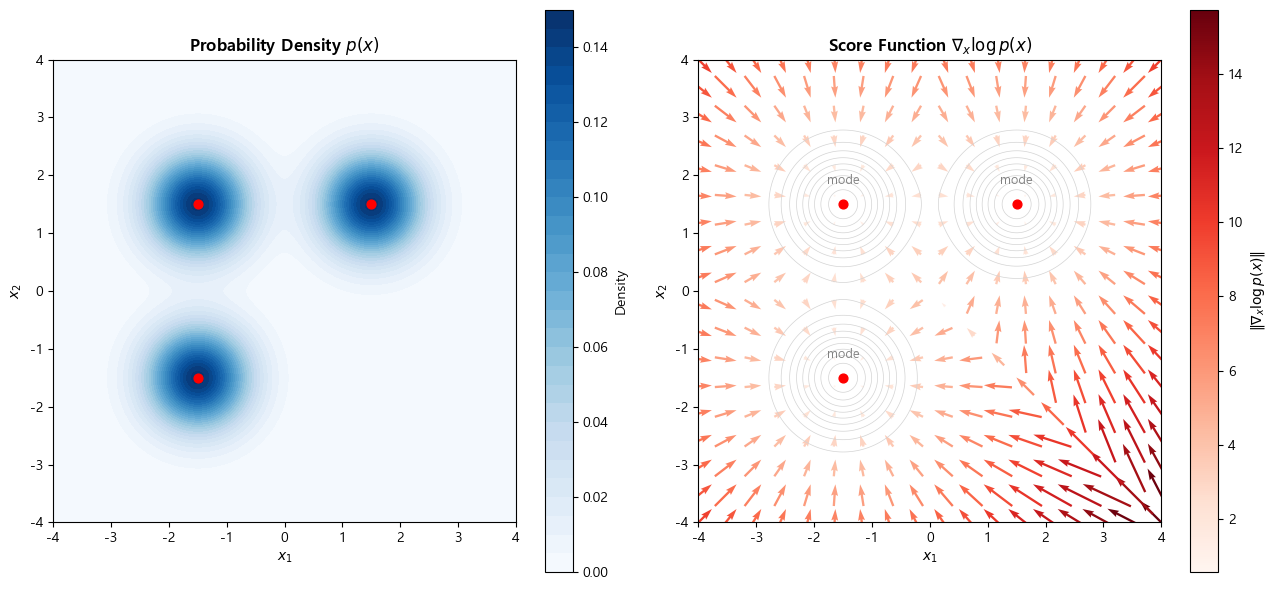

In [297]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

cf = ax1.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues")
cbar1 = fig.colorbar(cf, ax=ax1)
cbar1.set_label("Density")
ax1.scatter(means[:, 0], means[:, 1], c="red", s=40, zorder=5)
ax1.set_title(r"Probability Density $p(x)$", fontweight="bold")
ax1.set_xlabel(r"$x_1$")
ax1.set_ylabel(r"$x_2$")
ax1.set_xlim(-lim, lim)
ax1.set_ylim(-lim, lim)
ax1.set_aspect("equal")

ax2.contour(X1_fine, X2_fine, P, levels=10, colors="lightgray", linewidths=0.5)
q = ax2.quiver(
    X1_c, X2_c, U, V, magnitude,
    cmap="Reds", scale=120, width=0.005, pivot="mid",
)
cbar2 = fig.colorbar(q, ax=ax2)
cbar2.set_label(r"$\|\nabla_x \log p(x)\|$")
ax2.scatter(means[:, 0], means[:, 1], c="red", s=40, zorder=5)
for mu in means:
    ax2.annotate("mode", (mu[0], mu[1] + 0.35), ha="center", color="gray", fontsize=9)
ax2.set_title(r"Score Function $\nabla_x \log p(x)$", fontweight="bold")
ax2.set_xlabel(r"$x_1$")
ax2.set_ylabel(r"$x_2$")
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.set_aspect("equal")

plt.tight_layout()
plt.show()

## 6. 랜덤 점을 찍으면 어디에 분포할까?

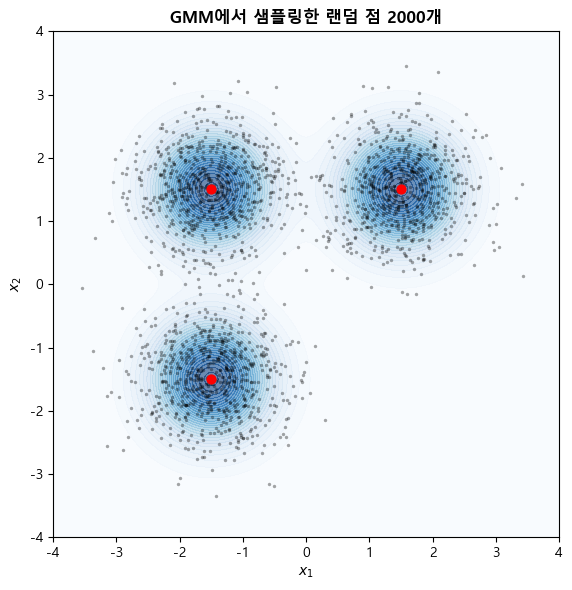

In [298]:
rng = np.random.default_rng(42)
n_samples = 2000

component_idx = rng.choice(len(means), size=n_samples, p=weights)
samples = means[component_idx] + rng.normal(scale=sigma, size=(n_samples, 2))

fig2, ax3 = plt.subplots(figsize=(6, 6))
ax3.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.6)
ax3.scatter(samples[:, 0], samples[:, 1], s=6, c="black", alpha=0.35, linewidths=0)
ax3.scatter(means[:, 0], means[:, 1], c="red", s=40, zorder=5)
ax3.set_title(f"GMM에서 샘플링한 랜덤 점 {n_samples}개", fontweight="bold")
ax3.set_xlabel(r"$x_1$")
ax3.set_ylabel(r"$x_2$")
ax3.set_xlim(-lim, lim)
ax3.set_ylim(-lim, lim)
ax3.set_aspect("equal")

plt.tight_layout()
plt.show()

## 7. 혼합 비율(weights)을 다르게 하면?

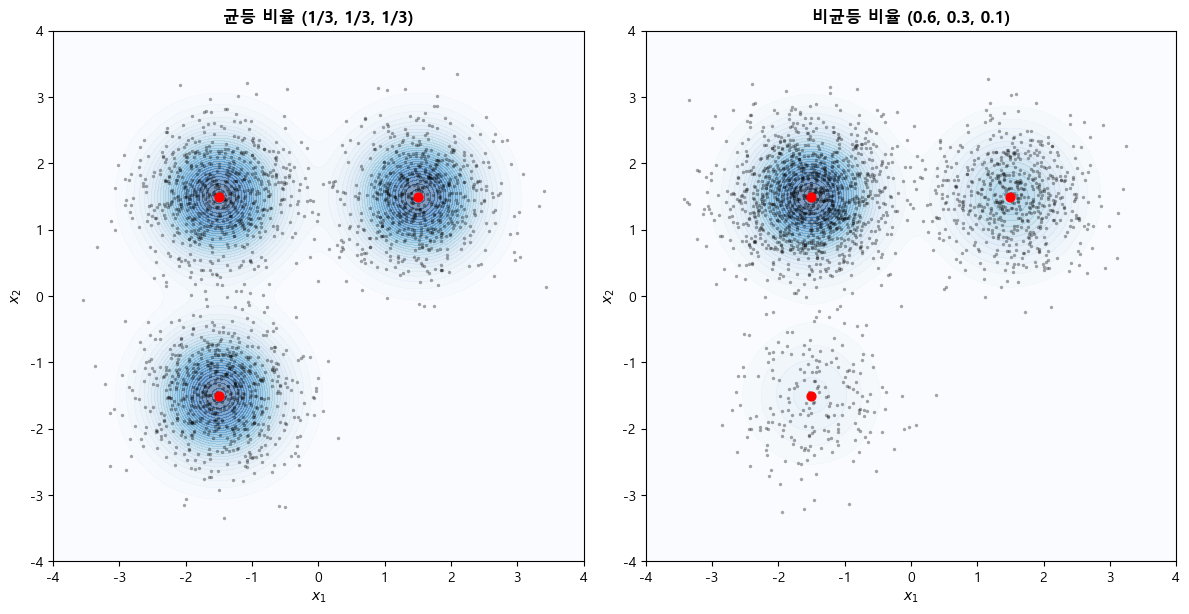

In [299]:
weights_uneven = np.array([0.6, 0.3, 0.1])

P_uneven = density(X1_fine, X2_fine, w=weights_uneven)
component_idx_uneven = rng.choice(len(means), size=n_samples, p=weights_uneven)
samples_uneven = means[component_idx_uneven] + rng.normal(scale=sigma, size=(n_samples, 2))

fig4, (axA, axB) = plt.subplots(1, 2, figsize=(12, 6))
for ax, s, p_bg, title in [
    (axA, samples, P, "균등 비율 (1/3, 1/3, 1/3)"),
    (axB, samples_uneven, P_uneven, "비균등 비율 (0.6, 0.3, 0.1)"),
]:
    ax.contourf(X1_fine, X2_fine, p_bg, levels=30, cmap="Blues", alpha=0.5)
    ax.scatter(s[:, 0], s[:, 1], s=6, c="black", alpha=0.35, linewidths=0)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=40, zorder=5)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 8. 점들이 스코어를 따라 이동하면?

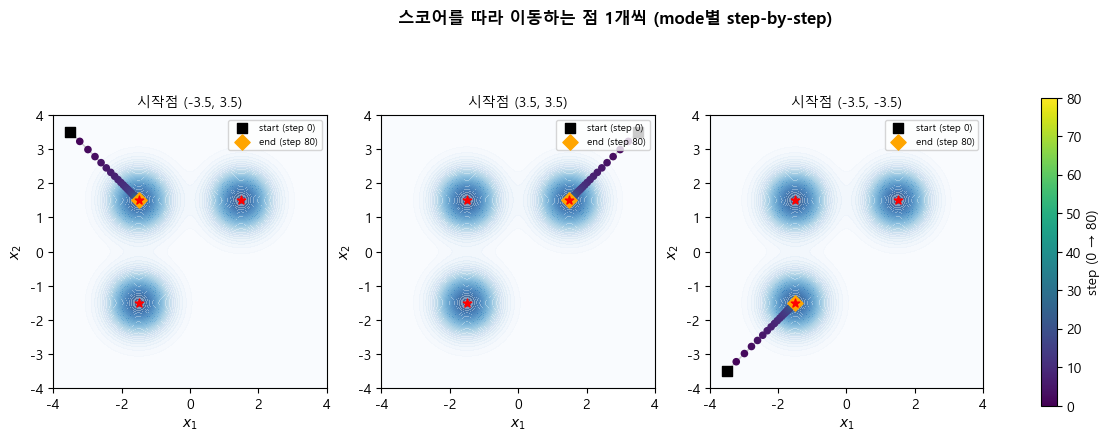

In [300]:
def follow_score(start_points, step_size=0.05, n_steps=80, noise_scale=0.0, noise_df=None, score_fn=None, rng=None):
    """x_{t+1} = x_t + step_size * score_fn(x_t) + noise_scale * noise
    noise_scale=0 이면 순수 gradient ascent.
    noise_df=None 이면 노이즈가 정규분포, 숫자를 주면 그 자유도의 t-분포(분산은 noise_scale^2으로 맞춤).
    score_fn을 안 주면 위에서 정의한 가우시안 혼합 score()를 쓴다 (다른 밀도의 score를 넣어도 됨)."""
    if score_fn is None:
        score_fn = score
    if rng is None:
        rng = np.random.default_rng(0)
    trajectories = np.zeros((n_steps + 1, *start_points.shape))
    trajectories[0] = start_points
    x = start_points.copy()
    for t in range(n_steps):
        gx, gy = score_fn(x[:, 0], x[:, 1])
        grad = np.stack([gx, gy], axis=1)
        if noise_scale > 0:
            if noise_df is not None:
                raw = rng.standard_t(noise_df, size=x.shape)
                noise = raw * (noise_scale / np.sqrt(noise_df / (noise_df - 2)))
            else:
                noise = rng.normal(scale=noise_scale, size=x.shape)
        else:
            noise = 0.0
        x = x + step_size * grad + noise
        trajectories[t + 1] = x
    return trajectories

start_points = np.array([
    [-3.5,  3.5],   # -> mode (-1.5, 1.5) 방향
    [ 3.5,  3.5],   # -> mode ( 1.5, 1.5) 방향
    [-3.5, -3.5],   # -> mode (-1.5,-1.5) 방향
])
step_size_demo = 0.05
n_steps_demo = 80
trajectories = follow_score(start_points, step_size=step_size_demo, n_steps=n_steps_demo, noise_scale=0.0)
step_idx = np.arange(n_steps_demo + 1)

fig3, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.plot(trajectories[:, i, 0], trajectories[:, i, 1], color="gray", alpha=0.4, linewidth=1, zorder=3)
    sc = ax.scatter(
        trajectories[:, i, 0], trajectories[:, i, 1],
        c=step_idx, cmap="viridis", s=20, zorder=4,
    )
    ax.scatter(*start_points[i], c="black", s=60, marker="s", zorder=5, label="start (step 0)")
    ax.scatter(*trajectories[-1, i], c="orange", s=60, marker="D", zorder=5, label=f"end (step {n_steps_demo})")
    ax.scatter(means[:, 0], means[:, 1], c="red", s=40, marker="*", zorder=5)
    ax.legend(loc="upper right", fontsize=7)
    ax.set_title(f"시작점 ({start_points[i, 0]}, {start_points[i, 1]})", fontsize=10)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

fig3.colorbar(sc, ax=axes, shrink=0.8, label="step (0 → 80)")
fig3.suptitle("스코어를 따라 이동하는 점 1개씩 (mode별 step-by-step)", fontweight="bold")

plt.show()

### 8-1. 노이즈를 더하면 (Langevin dynamics)

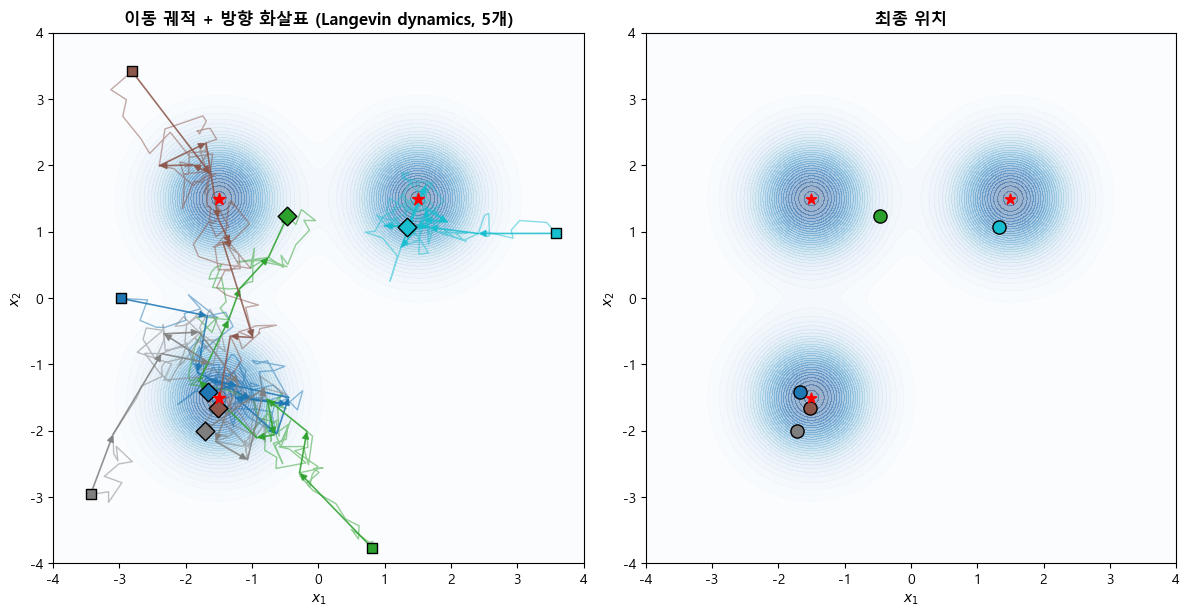

In [301]:
step_size = 0.02
n_steps_langevin = 100
n_particles_langevin = 5

rng3 = np.random.default_rng(11)
start_points_l = rng3.uniform(-lim, lim, size=(n_particles_langevin, 2))
trajectories_l = follow_score(
    start_points_l,
    step_size=step_size,
    n_steps=n_steps_langevin,
    noise_scale=np.sqrt(2 * step_size),
    rng=rng3,
)
final_points_l = trajectories_l[-1]

colors = plt.cm.tab10(np.linspace(0, 1, n_particles_langevin))
arrow_step = 10  # 몇 스텝마다 이동 방향 화살표를 하나씩 찍을지

fig5, (axC, axD) = plt.subplots(1, 2, figsize=(12, 6))

axC.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.4)
for i in range(n_particles_langevin):  # 5개뿐이니 다 진하게, 색도 다르게
    axC.plot(trajectories_l[:, i, 0], trajectories_l[:, i, 1], color=colors[i], alpha=0.5, linewidth=1, zorder=3)
    for t in range(0, n_steps_langevin, arrow_step):  # 진행 방향을 화살표로 표시
        t_next = min(t + arrow_step, n_steps_langevin)
        x0, y0 = trajectories_l[t, i]
        x1_, y1_ = trajectories_l[t_next, i]
        axC.annotate(
            "", xy=(x1_, y1_), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color=colors[i], alpha=0.85, lw=1.2, shrinkA=0, shrinkB=0),
            zorder=4,
        )
    axC.scatter(*start_points_l[i], color=colors[i], s=60, marker="s", zorder=5, edgecolor="black")
    axC.scatter(*final_points_l[i], color=colors[i], s=90, marker="D", zorder=6, edgecolor="black")
axC.scatter(means[:, 0], means[:, 1], c="red", s=80, marker="*", zorder=7)
axC.set_title(f"이동 궤적 + 방향 화살표 (Langevin dynamics, {n_particles_langevin}개)", fontweight="bold")

axD.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.4)
for i in range(n_particles_langevin):
    axD.scatter(*final_points_l[i], color=colors[i], s=90, zorder=5, edgecolor="black")
axD.scatter(means[:, 0], means[:, 1], c="red", s=60, marker="*", zorder=6)
axD.set_title("최종 위치", fontweight="bold")

for ax in (axC, axD):
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 8-2. 비율(0.7, 0.2, 0.1)로, 시작점도 분포 자체에서 뽑아서 Langevin dynamics

시작 개수 (mode별): [176, 166, 158]
최종 개수 (mode별): [179, 160, 161]

전이표 (행=출발 비율, 열=최종 mode)
              최종1  최종2  최종3
출발 비율 0.333333  144     13     19
출발 비율 0.333333   18    145      3
출발 비율 0.333333   17      2    139

시작 mode와 최종 mode가 다른 점: 72/500개
threshold(1.5) 벗어난 극단값: 17/500개


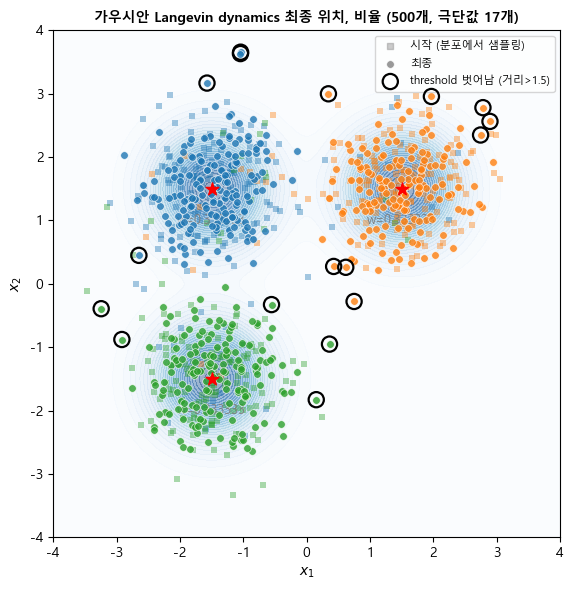

In [329]:
step_size = 0.02
n_steps_langevin = 100
n_particles_langevin = 500

weights_073 = np.array([1/3, 1/3, 1/3])  # <- 비율을 균등하게 하려면 이 줄로 교체
P_073 = density(X1_fine, X2_fine, w=weights_073)
score_073 = lambda x1, x2: score(x1, x2, w=weights_073)

rng5 = np.random.default_rng(11)
comp_idx_start = rng5.choice(len(means), size=n_particles_langevin, p=weights_073)
start_points_l100 = means[comp_idx_start] + rng5.normal(scale=sigma, size=(n_particles_langevin, 2))

trajectories_l100 = follow_score(
    start_points_l100,
    step_size=step_size,
    n_steps=n_steps_langevin,
    noise_scale=np.sqrt(2 * step_size),
    score_fn=score_073,
    rng=rng5,
)
final_points_l100 = trajectories_l100[-1]

mode_colors = ['tab:blue', 'tab:orange', 'tab:green']
dist_to_modes = np.linalg.norm(final_points_l100[:, None, :] - means[None, :, :], axis=2)
labels_l100 = np.argmin(dist_to_modes, axis=1)

extreme_threshold_l100 = 1.5
final_dist_to_nearest = dist_to_modes.min(axis=1)
is_extreme_l100 = final_dist_to_nearest > extreme_threshold_l100

print('시작 개수 (mode별):', [int(np.sum(comp_idx_start == i)) for i in range(3)])
print('최종 개수 (mode별):', [int(np.sum(labels_l100 == i)) for i in range(3)])
print()
transition = np.zeros((3, 3), dtype=int)
for i in range(3):
    for j in range(3):
        transition[i, j] = int(np.sum((comp_idx_start == i) & (labels_l100 == j)))

row_labels = [f'출발 비율 {wk:g}' for wk in weights_073]
print('전이표 (행=출발 비율, 열=최종 mode)')
print('              최종1  최종2  최종3')
for i in range(3):
    row = '  '.join(f'{transition[i, j]:>5}' for j in range(3))
    print(f'{row_labels[i]:<14}{row}')
n_moved = int(np.sum(comp_idx_start != labels_l100))
print()
print(f'시작 mode와 최종 mode가 다른 점: {n_moved}/{n_particles_langevin}개')
print(f'threshold({extreme_threshold_l100}) 벗어난 극단값: {int(is_extreme_l100.sum())}/{n_particles_langevin}개')

lim_073 = max(lim, float(np.abs(start_points_l100).max()) * 1.05)

fig, ax = plt.subplots(figsize=(6, 6))
ax.contourf(X1_fine, X2_fine, P_073, levels=30, cmap='Blues', alpha=0.4)
for lbl in [0, 1, 2]:
    mask = labels_l100 == lbl
    color = mode_colors[lbl]
    ax.scatter(start_points_l100[mask, 0], start_points_l100[mask, 1], s=15, color=color, alpha=0.4, marker='s', linewidths=0)
    ax.scatter(final_points_l100[mask, 0], final_points_l100[mask, 1], s=30, color=color, alpha=0.8, edgecolor='white', linewidths=0.5, zorder=5)
ax.scatter(final_points_l100[is_extreme_l100, 0], final_points_l100[is_extreme_l100, 1], s=120, facecolors='none', edgecolors='black', linewidths=1.6, marker='o', zorder=6)
ax.scatter([], [], s=15, color='gray', alpha=0.4, marker='s', label='시작 (분포에서 샘플링)')
ax.scatter([], [], s=30, color='gray', alpha=0.8, edgecolor='white', linewidths=0.5, label='최종')
ax.scatter([], [], s=120, facecolors='none', edgecolors='black', linewidths=1.6, marker='o', label=f'threshold 벗어남 (거리>{extreme_threshold_l100})')
ax.scatter(means[:, 0], means[:, 1], c='red', s=90, marker='*', zorder=7)
for mu, wk in zip(means, weights_073):
    ax.annotate(f'w={wk:g}', (mu[0], mu[1] - 0.55), ha='center', color='gray', fontsize=9)
ax.set_title(f'가우시안 Langevin dynamics 최종 위치, 비율 ({n_particles_langevin}개, 극단값 {int(is_extreme_l100.sum())}개)', fontweight='bold', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_xlim(-lim_073, lim_073)
ax.set_ylim(-lim_073, lim_073)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 9. step_size를 너무 크게 잡으면 어떻게 될까? (안정성 실험)

In [310]:
print(f"Stability threshold: step_size < 2*sigma^2 = {2 * sigma ** 2:.2f}")

for step in [0.05, 0.3, 0.5, 0.72, 0.9, 1.5, 3.0]:
    rng_test = np.random.default_rng(0)
    start_test = rng_test.uniform(-lim, lim, size=(200, 2))
    traj_test = follow_score(start_test, step_size=step, n_steps=60, noise_scale=0.0, rng=rng_test)
    final_test = traj_test[-1]
    finite_mask = np.isfinite(final_test).all(axis=1) & (np.abs(final_test) < 50).all(axis=1)
    n_diverged = 200 - finite_mask.sum()
    if finite_mask.sum() > 0:
        dist_to_nearest = np.min(
            np.linalg.norm(final_test[finite_mask, None, :] - means[None, :, :], axis=2), axis=1
        )
        n_close = int(np.sum(dist_to_nearest < 0.3))
    else:
        n_close = 0
    print(f"step={step:>5}: close_to_mode={n_close}/200  diverged={n_diverged}/200")

Stability threshold: step_size < 2*sigma^2 = 0.72
step= 0.05: close_to_mode=200/200  diverged=0/200
step=  0.3: close_to_mode=200/200  diverged=0/200
step=  0.5: close_to_mode=200/200  diverged=0/200
step= 0.72: close_to_mode=3/200  diverged=0/200
step=  0.9: close_to_mode=0/200  diverged=168/200
step=  1.5: close_to_mode=0/200  diverged=200/200
step=  3.0: close_to_mode=0/200  diverged=200/200


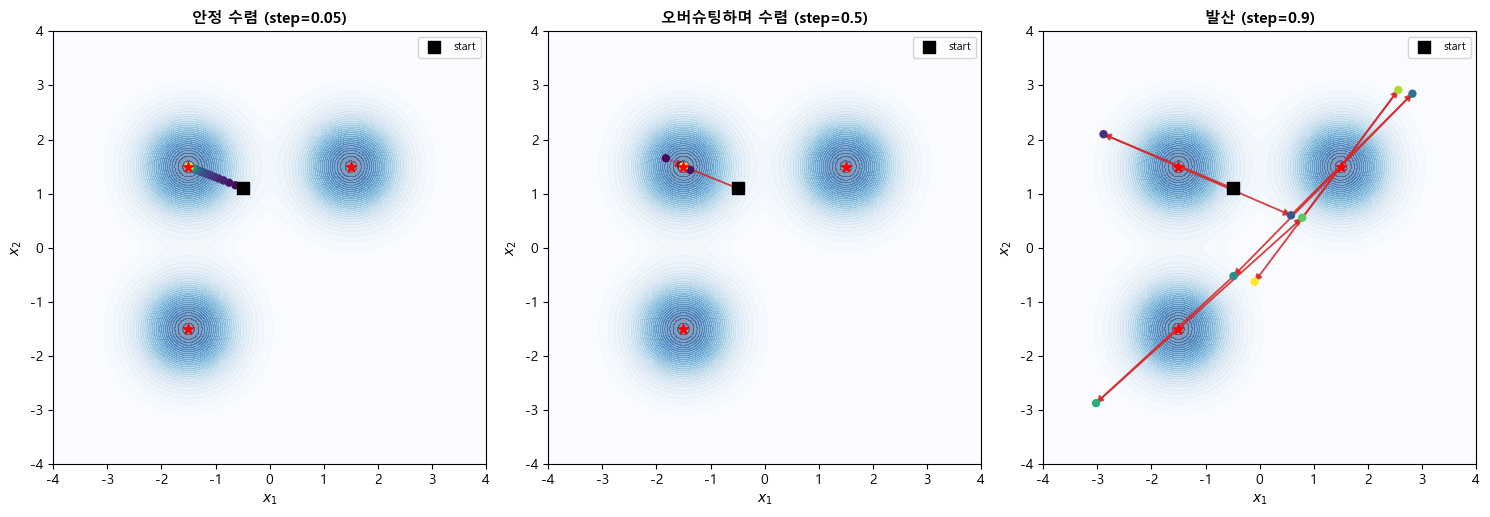

In [311]:
start_demo = np.array([[-1.5 + 1.0, 1.5 - 0.4]])  # mode1 근처에서 살짝 벗어난 점
stability_cases = [
    (0.05, "안정 수렴 (step=0.05)", 40),
    (0.5, "오버슈팅하며 수렴 (step=0.5)", 40),
    (0.9, "발산 (step=0.9)", 8),
]

fig7, axes7 = plt.subplots(1, 3, figsize=(15, 5))
for (step, title, n_steps_stab), ax in zip(stability_cases, axes7):
    traj_demo = follow_score(start_demo, step_size=step, n_steps=n_steps_stab, noise_scale=0.0)
    step_idx_demo = np.arange(n_steps_stab + 1)
    arrow_interval = max(1, n_steps_stab // 8)  # 스텝마다 이동 방향을 화살표로 표시
    ax.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax.plot(traj_demo[:, 0, 0], traj_demo[:, 0, 1], color="tab:red", alpha=0.4, linewidth=1, zorder=3)
    for t in range(0, n_steps_stab, arrow_interval):
        t_next = min(t + arrow_interval, n_steps_stab)
        x0, y0 = traj_demo[t, 0]
        x1_, y1_ = traj_demo[t_next, 0]
        ax.annotate(
            "", xy=(x1_, y1_), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color="tab:red", alpha=0.8, lw=1.3, shrinkA=0, shrinkB=0),
            zorder=4,
        )
    ax.scatter(traj_demo[:, 0, 0], traj_demo[:, 0, 1], c=step_idx_demo, cmap="viridis", s=25, zorder=5)
    ax.scatter(*start_demo[0], c="black", s=70, marker="s", zorder=6, label="start")
    ax.scatter(means[:, 0], means[:, 1], c="red", s=60, marker="*", zorder=6)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    if step < 0.8:
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

### 9-1. 노이즈를 추가하면 (Langevin dynamics의 안정성)

In [312]:
def theoretical_variance(step_size, sigma):
    denom = 2 * sigma ** 2 - step_size
    return 2 * sigma ** 4 / denom if denom > 0 else np.inf

print("Langevin dynamics: 이론 vs 실측 정상분포 분산 (noise_scale = sqrt(2*step_size))")
print(f"(목표: step->0 일 때 empirical_var -> sigma^2 = {sigma ** 2:.3f})\n")

for step in [0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.5]:
    rng_v = np.random.default_rng(0)
    start_v = rng_v.uniform(-lim, lim, size=(500, 2))
    traj_v = follow_score(start_v, step_size=step, n_steps=300, noise_scale=np.sqrt(2 * step), rng=rng_v)
    final_v = traj_v[-1]
    finite_mask = np.isfinite(final_v).all(axis=1) & (np.abs(final_v) < 50).all(axis=1)
    n_diverged = 500 - int(finite_mask.sum())
    if finite_mask.sum() > 0:
        nearest_idx = np.argmin(
            np.linalg.norm(final_v[finite_mask, None, :] - means[None, :, :], axis=2), axis=1
        )
        offsets = final_v[finite_mask] - means[nearest_idx]
        empirical_var = float(offsets.var())
    else:
        empirical_var = float("nan")
    theory_var = theoretical_variance(step, sigma)
    print(f"step={step:>4}: theory_var={theory_var:6.3f}  empirical_var={empirical_var:6.3f}  diverged={n_diverged}/500")

Langevin dynamics: 이론 vs 실측 정상분포 분산 (noise_scale = sqrt(2*step_size))
(목표: step->0 일 때 empirical_var -> sigma^2 = 0.360)

step=0.02: theory_var= 0.370  empirical_var= 0.344  diverged=0/500
step=0.05: theory_var= 0.387  empirical_var= 0.379  diverged=0/500
step= 0.1: theory_var= 0.418  empirical_var= 0.418  diverged=0/500
step= 0.2: theory_var= 0.498  empirical_var= 0.515  diverged=0/500
step= 0.3: theory_var= 0.617  empirical_var= 0.633  diverged=0/500
step= 0.5: theory_var= 1.178  empirical_var= 0.934  diverged=0/500
step= 0.7: theory_var=12.960  empirical_var= 2.129  diverged=0/500
step= 0.9: theory_var=   inf  empirical_var=   nan  diverged=500/500
step= 1.5: theory_var=   inf  empirical_var=   nan  diverged=500/500


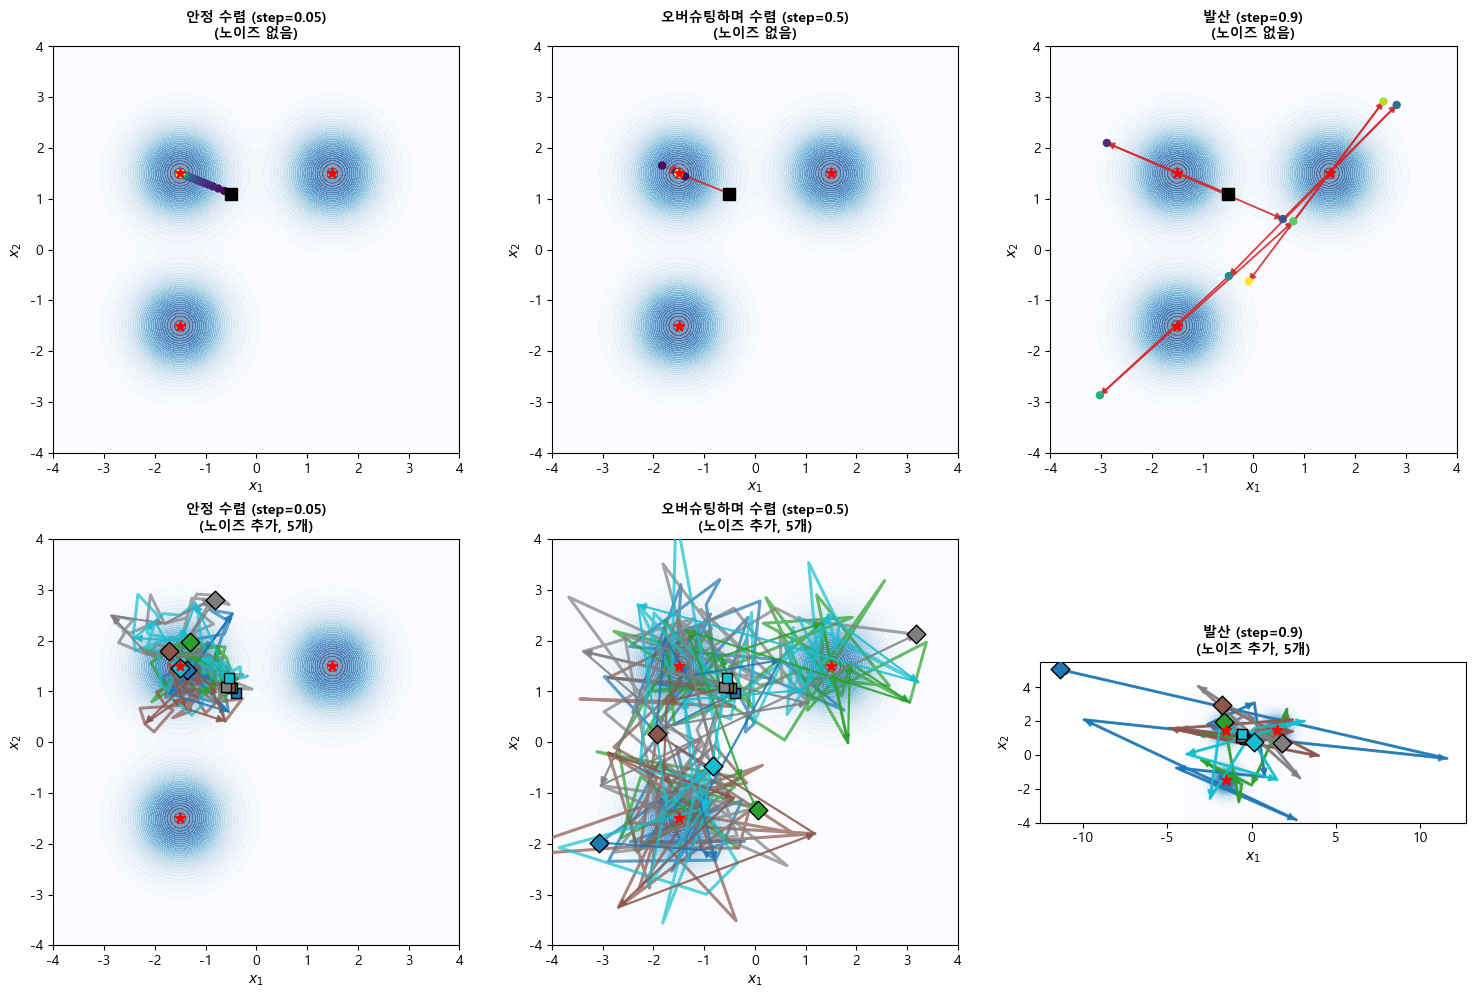

In [313]:
n_particles_stab = 5
colors_stab = plt.cm.tab10(np.linspace(0, 1, n_particles_stab))

fig8, axes8 = plt.subplots(2, 3, figsize=(15, 10))
for col, (step, title, n_steps_stab) in enumerate(stability_cases):
    arrow_interval = max(1, n_steps_stab // 8)

    ax_top = axes8[0, col]
    traj_demo = follow_score(start_demo, step_size=step, n_steps=n_steps_stab, noise_scale=0.0)
    step_idx_demo = np.arange(n_steps_stab + 1)
    ax_top.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    ax_top.plot(traj_demo[:, 0, 0], traj_demo[:, 0, 1], color="tab:red", alpha=0.4, linewidth=1, zorder=3)
    for t in range(0, n_steps_stab, arrow_interval):
        t_next = min(t + arrow_interval, n_steps_stab)
        x0, y0 = traj_demo[t, 0]
        x1_, y1_ = traj_demo[t_next, 0]
        ax_top.annotate(
            "", xy=(x1_, y1_), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="-|>", color="tab:red", alpha=0.8, lw=1.3, shrinkA=0, shrinkB=0),
            zorder=4,
        )
    ax_top.scatter(traj_demo[:, 0, 0], traj_demo[:, 0, 1], c=step_idx_demo, cmap="viridis", s=25, zorder=5)
    ax_top.scatter(*start_demo[0], c="black", s=70, marker="s", zorder=6)
    ax_top.scatter(means[:, 0], means[:, 1], c="red", s=60, marker="*", zorder=6)
    ax_top.set_title(f"{title}\n(노이즈 없음)", fontsize=10, fontweight="bold")

    ax_bot = axes8[1, col]
    rng_stab = np.random.default_rng(3)
    start_multi = start_demo + rng_stab.normal(scale=0.05, size=(n_particles_stab, 2))
    traj_multi = follow_score(
        start_multi, step_size=step, n_steps=n_steps_stab,
        noise_scale=np.sqrt(2 * step), rng=rng_stab,
    )
    ax_bot.contourf(X1_fine, X2_fine, P, levels=30, cmap="Blues", alpha=0.5)
    for i in range(n_particles_stab):
        ax_bot.plot(
            traj_multi[:, i, 0], traj_multi[:, i, 1],
            color=colors_stab[i], alpha=0.7, linewidth=2.2, zorder=3,
        )
        for t in range(0, n_steps_stab, arrow_interval):
            t_next = min(t + arrow_interval, n_steps_stab)
            x0, y0 = traj_multi[t, i]
            x1_, y1_ = traj_multi[t_next, i]
            ax_bot.annotate(
                "", xy=(x1_, y1_), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=colors_stab[i], alpha=0.85, lw=1.6, shrinkA=0, shrinkB=0),
                zorder=4,
            )
        ax_bot.scatter(*start_multi[i], color=colors_stab[i], s=60, marker="s", zorder=5, edgecolor="black")
        ax_bot.scatter(*traj_multi[-1, i], color=colors_stab[i], s=90, marker="D", zorder=6, edgecolor="black")
    ax_bot.scatter(means[:, 0], means[:, 1], c="red", s=60, marker="*", zorder=7)
    ax_bot.set_title(f"{title}\n(노이즈 추가, {n_particles_stab}개)", fontsize=10, fontweight="bold")

    for ax in (ax_top, ax_bot):
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        if step < 0.8:
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
        ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## 10. 비율이 다를 때 샘플 10개는 어디로 몰릴까?

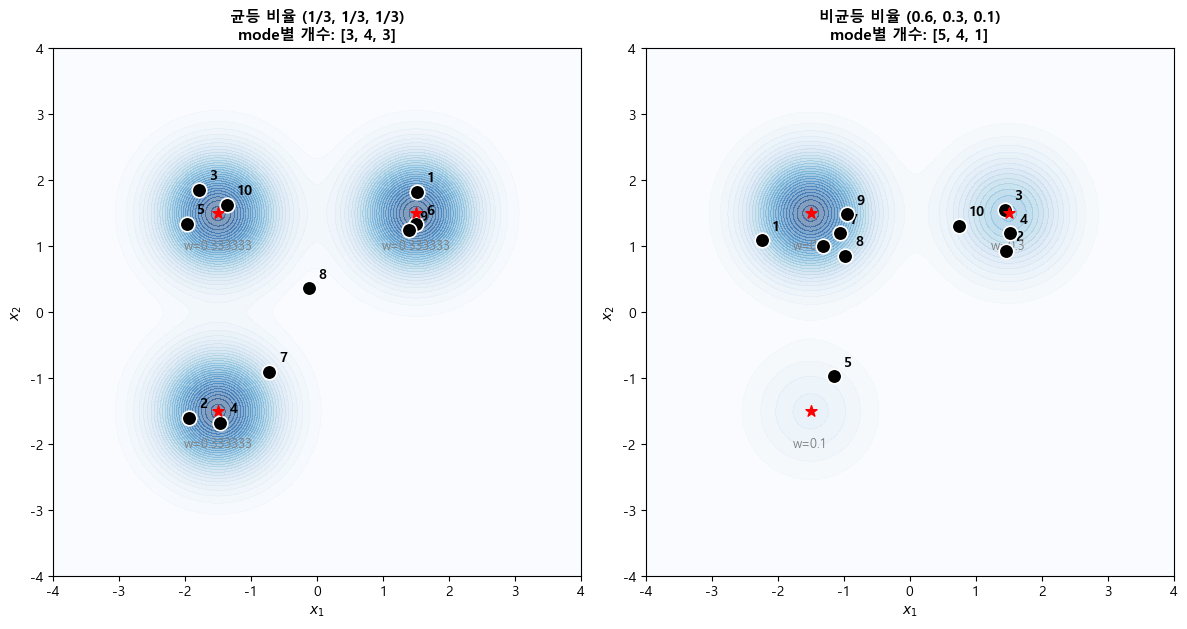

In [314]:
n_samples_small = 10
rng_small = np.random.default_rng(1)

comp_idx_eq = rng_small.choice(len(means), size=n_samples_small, p=weights)
samples_eq_small = means[comp_idx_eq] + rng_small.normal(scale=sigma, size=(n_samples_small, 2))

comp_idx_uneq = rng_small.choice(len(means), size=n_samples_small, p=weights_uneven)
samples_uneq_small = means[comp_idx_uneq] + rng_small.normal(scale=sigma, size=(n_samples_small, 2))

fig9, (axE, axF) = plt.subplots(1, 2, figsize=(12, 6))
for ax, s, comp_idx, p_bg, w, title in [
    (axE, samples_eq_small, comp_idx_eq, P, weights, "균등 비율 (1/3, 1/3, 1/3)"),
    (axF, samples_uneq_small, comp_idx_uneq, P_uneven, weights_uneven, "비균등 비율 (0.6, 0.3, 0.1)"),
]:
    ax.contourf(X1_fine, X2_fine, p_bg, levels=30, cmap="Blues", alpha=0.5)
    ax.scatter(s[:, 0], s[:, 1], c="black", s=110, zorder=5, edgecolor="white", linewidth=1.2)
    for i, (x, y) in enumerate(s):
        ax.annotate(str(i + 1), (x, y), textcoords="offset points", xytext=(7, 7), fontsize=10, fontweight="bold")
    ax.scatter(means[:, 0], means[:, 1], c="red", s=70, marker="*", zorder=6)
    for mu, wk in zip(means, w):
        ax.annotate(f"w={wk:g}", (mu[0], mu[1] - 0.55), ha="center", color="gray", fontsize=9)
    counts = [int(c) for c in np.bincount(comp_idx, minlength=len(means))]
    ax.set_title(f"{title}\nmode별 개수: {counts}", fontweight="bold", fontsize=11)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### 10-1. 직접 샘플링하면 극단값이 얼마나 나올까? (비율 0.7/0.2/0.1)

500개 직접 샘플링 (가우시안 혼합, 비율 0.7/0.2/0.1)
평균 거리: 0.731   중간값: 0.715   최댓값: 2.251

threshold별 극단값(mode까지 거리 > threshold) 개수
threshold= 1.0:  107개 (21.4%)
threshold= 1.5:    9개 (1.8%)
threshold= 2.0:    1개 (0.2%)
threshold= 2.5:    0개 (0.0%)
threshold= 3.0:    0개 (0.0%)
threshold= 4.0:    0개 (0.0%)


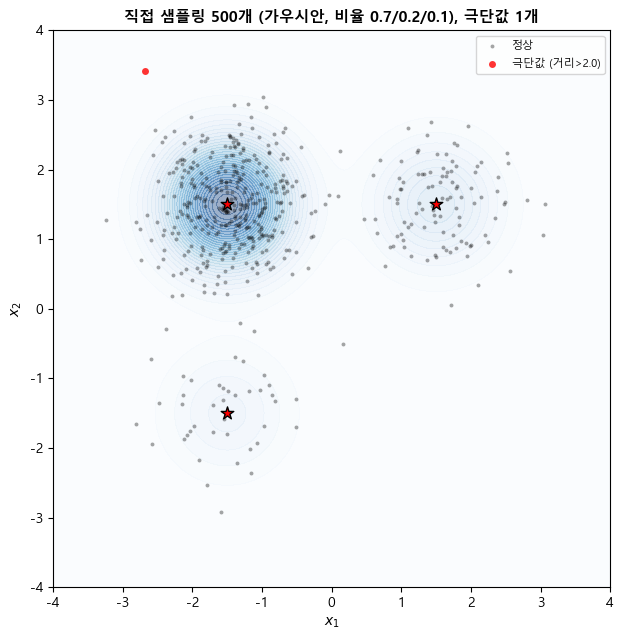

In [325]:
weights_073_g = np.array([0.7, 0.2, 0.1])
P_073_g = density(X1_fine, X2_fine, w=weights_073_g)

n_samples_ext = 500
rng6 = np.random.default_rng(3)
comp_idx_ext = rng6.choice(len(means), size=n_samples_ext, p=weights_073_g)
samples_ext_g = means[comp_idx_ext] + rng6.normal(scale=sigma, size=(n_samples_ext, 2))

dist_ext_g = np.min(np.linalg.norm(samples_ext_g[:, None, :] - means[None, :, :], axis=2), axis=1)

print(f'{n_samples_ext}개 직접 샘플링 (가우시안 혼합, 비율 0.7/0.2/0.1)')
print(f'평균 거리: {dist_ext_g.mean():.3f}   중간값: {np.median(dist_ext_g):.3f}   최댓값: {dist_ext_g.max():.3f}')
print()
print('threshold별 극단값(mode까지 거리 > threshold) 개수')
for thr in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    n_ext_thr = int(np.sum(dist_ext_g > thr))
    print(f'threshold={thr:>4}: {n_ext_thr:>4}개 ({100*n_ext_thr/n_samples_ext:.1f}%)')

lim_ext_g = max(lim, float(np.abs(samples_ext_g).max()) * 1.05)

extreme_thr_plot = 2.0
is_extreme_g = dist_ext_g > extreme_thr_plot

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.contourf(X1_fine, X2_fine, P_073_g, levels=30, cmap='Blues', alpha=0.4)
ax.scatter(samples_ext_g[~is_extreme_g, 0], samples_ext_g[~is_extreme_g, 1], s=8, c='black', alpha=0.35, linewidths=0, label='정상')
ax.scatter(samples_ext_g[is_extreme_g, 0], samples_ext_g[is_extreme_g, 1], s=25, c='red', alpha=0.8, linewidths=0, label=f'극단값 (거리>{extreme_thr_plot})')
ax.scatter(means[:, 0], means[:, 1], c='red', s=90, marker='*', zorder=6, edgecolor='black')
ax.set_title(f'직접 샘플링 {n_samples_ext}개 (가우시안, 비율 0.7/0.2/0.1), 극단값 {int(is_extreme_g.sum())}개', fontweight='bold', fontsize=11)
ax.legend(loc='upper right', fontsize=8)
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_xlim(-lim_ext_g, lim_ext_g)
ax.set_ylim(-lim_ext_g, lim_ext_g)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()